<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB53 · Zancudo 3D

**Parte 6 · Simulación de bípedos a fondo — Bloque C: del plano al 3D — Lección 1**

> Hasta ahora, Zancudo ha vivido en un **plano**, como un dibujo animado de perfil: podía ir hacia delante y hacia atrás, subir y bajar, y cabecear. Pero no podía **caerse de lado**, ni **girar**. Era una trampa cómoda: el equilibrio lateral, que es la mitad del problema de andar, simplemente no existía. Los robots de verdad viven en 3D. Hoy Zancudo también.

Vamos a reconstruirlo **desde cero con `MjSpec`** (NB50), con piernas de humanoide de verdad: **6 articulaciones por pierna** (3 en la cadera, 1 en la rodilla, 2 en el tobillo), pies planos de verdad, y un torso **libre** en el espacio. Y le pediremos tres cosas:

1. **Estar de pie sin hundirse**: con la gravedad compensada, repartiendo su peso entre los pies.
2. **Sostenerse a la pata coja**: llevar todo el peso sobre un pie y levantar el otro. Es la prueba clásica de equilibrio lateral, y el primer paso de cualquier marcha en 3D.
3. **Aguantar empujones de lado**, y comprobar con números lo que predice el LIPM del NB51 (que ya hicimos en 2D, con x e y).

Preguntas de entrevista que vas a poder contestar:

- "¿Qué es una base flotante? ¿Por qué `nq` y `nv` no coinciden en un humanoide?"
- "¿En qué marco está la velocidad angular de una junta libre en MuJoCo?"
- "¿Qué articulaciones tiene la pierna de un humanoide y por qué?"
- "¿Cómo calculas los pares para que un robot esté de pie, si el suelo también empuja?"
- "¿Qué es el reparto de fuerzas (*force distribution*) entre los pies?"
- "¿De qué depende cuánto empujón lateral aguanta un bípedo?"

En el hilo de Python: la **configuración profesional**. Un robot (o un experimento) tiene decenas de números: medidas, masas, ganancias... ¿Dónde se guardan? ¿Cómo se comprueba que son correctos? ¿Cómo se prueban variantes sin tocar el código? Con **dataclasses** anidadas y ficheros **YAML**.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"

import math
import mujoco
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("MuJoCo", mujoco.__version__)

MuJoCo 3.14.0


## 1 · La base flotante

### Seis grados de libertad que nadie mueve

En el Zancudo plano, el torso tenía **tres** articulaciones "de mentira" que lo unían al mundo: deslizar en x, deslizar en z y girar alrededor de y (NB42). En 3D, un cuerpo libre se puede mover de **seis** formas: tres desplazamientos (x, y, z) y tres giros (alrededor de x, de y y de z). Ninguna tiene motor: el torso solo se mueve porque las piernas empujan el suelo. Se llama **base flotante** (*floating base*), y es lo que tienen todos los robots con patas (NB47: un robot **subactuado**).

En MuJoCo, la base flotante es una **junta libre** (*free joint*, `<freejoint/>` en MJCF). Construyamos el ejemplo más pequeño posible, una caja libre sin gravedad, para conocerla:


In [2]:
CAJA_LIBRE = '''
<mujoco>
  <option gravity="0 0 0"/>
  <worldbody>
    <body name="caja">
      <freejoint name="libre"/>
      <geom type="box" size="0.1 0.2 0.3"/>
    </body>
  </worldbody>
</mujoco>
'''
caja = mujoco.MjModel.from_xml_string(CAJA_LIBRE)
print("nq =", caja.nq, "  nv =", caja.nv)

nq = 7   nv = 6


**nq = 7, pero nv = 6.** ¿Cómo puede ser que haya 7 números de posición y solo 6 de velocidad? Por la orientación:

- `qpos` guarda la posición (x, y, z: 3 números) y la orientación como un **cuaternión** (w, x, y, z: 4 números, NB46). Total, 7.
- `qvel` guarda la velocidad lineal (3) y la **velocidad angular** (3). Total, 6.

La orientación tiene 3 grados de libertad, pero el cuaternión usa 4 números (con la condición de que su longitud sea 1). Por eso un humanoide de 12 motores tiene **nq = 19** y **nv = 18**. Esto tiene consecuencias muy prácticas:

1. **No se puede restar `qpos`**. Dos cuaterniones no se restan para ver "cuánto ha girado" (NB46: hay que componer giros). Para comparar dos posturas, MuJoCo da **`mj_differentiatePos`**, que devuelve la diferencia como una velocidad (nv números); y para avanzar una postura con una velocidad, **`mj_integratePos`**.
2. **Las tablas que van con `qvel`** (jacobianos, `qfrc_bias`, la matriz de masas...) tienen **nv** columnas, no nq. Por eso, en la junta libre, `qpos[0:7]` corresponde a `qvel[0:6]`, y los motores empiezan en `qpos[7]` pero en `qvel[6]`. Confundirlos es uno de los fallos más frecuentes al pasar de 2D a 3D.


In [3]:
d = mujoco.MjData(caja)
q_inicial = d.qpos.copy()                       # en el origen, sin girar: cuaternión (1, 0, 0, 0)
d.qvel[:] = [0.1, 0, 0, 0, 0, 0.5]              # avanza en x y gira alrededor de z
for _ in range(1000):                           # 2 s
    mujoco.mj_step(caja, d)

diferencia = np.zeros(caja.nv)
mujoco.mj_differentiatePos(caja, diferencia, 1.0, q_inicial, d.qpos)
print("qpos final:", d.qpos)
print("restar a lo bruto:", d.qpos - q_inicial, "← ¡7 números sin sentido!")
print("mj_differentiatePos:", diferencia, "← 6 números: 0,2 m en x y 1 rad en z")

qpos final: [0.2    0.     0.     0.8776 0.     0.     0.4794]
restar a lo bruto: [ 0.2     0.      0.     -0.1224  0.      0.      0.4794] ← ¡7 números sin sentido!
mj_differentiatePos: [0.2 0.  0.  0.  0.  1. ] ← 6 números: 0,2 m en x y 1 rad en z


(`mj_differentiatePos(modelo, resultado, dt, q1, q2)` calcula la velocidad que llevaría de q1 a q2 en un tiempo dt; con dt = 1, es simplemente "la diferencia".) Tras 2 segundos: 0,2 m en x y 1 rad de giro alrededor de z. Exacto. Restando a lo bruto, salen 7 números que mezclan el cuaternión sin ningún significado.

### La trampa del marco de la velocidad angular

Una pregunta de entrevista con mala idea: los 3 números de velocidad angular de una junta libre, `qvel[3:6]`, ¿en qué ejes están: los del mundo, o los del propio cuerpo? Comprobémoslo: giramos la caja 90° alrededor del eje z vertical, le ponemos `qvel[3:6] = (1, 0, 0)`, "girar alrededor de x", y preguntamos a MuJoCo cómo gira **vista desde el mundo** (con `mj_objectVelocity`, que da la velocidad de un objeto en el marco que pidas; el último argumento, 0, significa "en el mundo"):


In [4]:
d = mujoco.MjData(caja)
d.qpos[3:7] = [math.cos(math.pi / 4), 0, 0, math.sin(math.pi / 4)]   # 90° alrededor de z (NB46)
d.qvel[3:6] = [1, 0, 0]
mujoco.mj_forward(caja, d)
velocidad = np.zeros(6)
mujoco.mj_objectVelocity(caja, d, mujoco.mjtObj.mjOBJ_BODY, caja.body("caja").id, velocidad, 0)
print("giro visto desde el mundo:", velocidad[:3].round(6))

giro visto desde el mundo: [0. 1. 0.]


Le pedimos girar "alrededor de x" y, vista desde el mundo, gira alrededor de **y**. Porque `qvel[3:6]` está en el **marco local** del cuerpo: el eje x **de la caja**, que tras girar 90° apunta hacia la y del mundo. En cambio, la velocidad **lineal**, `qvel[0:3]`, está en el marco del **mundo**.

> **Junta libre de MuJoCo**: `qvel[0:3]` = velocidad lineal en el **mundo**; `qvel[3:6]` = velocidad angular en el marco **local** del cuerpo.

Es justo lo que mide un **giróscopo** pegado al cuerpo (NB41), y lo que verás en las observaciones de los entornos de locomoción (NB54). Si alguna vez te sale un robot que "gira raro", mira esto lo primero.


## 2 · La pierna de un humanoide: 6 articulaciones

### Qué hace cada una

La pierna humana tiene muchísimos movimientos, pero para andar bastan seis, y casi todos los humanoides (Atlas, H1, G1, Digit, Optimus...) tienen esos seis o muy parecidos:

| Articulación | Eje | Movimiento | Para qué sirve |
|---|---|---|---|
| **Cadera, giro** (*yaw*) | z (vertical) | girar la pierna como una peonza | cambiar de dirección |
| **Cadera, lado** (*roll*) | x (hacia delante) | abrir la pierna hacia fuera | equilibrio lateral, pasar el peso de un pie a otro |
| **Cadera** (*pitch*) | y (lateral) | adelantar la pierna | dar el paso (la única que tenía el Zancudo plano) |
| **Rodilla** (*pitch*) | y | doblar | subir y bajar, amortiguar |
| **Tobillo** (*pitch*) | y | punta arriba/abajo | apoyar el pie plano, empujar |
| **Tobillo, lado** (*roll*) | x | inclinar el pie hacia los lados | apoyar el pie plano con la pierna inclinada |

(*Yaw*, *pitch* y *roll*: guiñada, cabeceo y alabeo, los ángulos de Euler del NB46.)

Las tres de la cadera se cruzan en un punto: juntas forman casi una **rótula**, como la cadera humana. Y las dos del tobillo, casi otra. El **orden** importa (NB46: los giros no conmutan): nosotros usaremos giro → lado → cabeceo en la cadera, y cabeceo → lado en el tobillo. Cada fabricante elige el suyo; lo verás en los robots reales del NB58.

### Varias articulaciones en un solo cuerpo

¿Cómo se ponen tres articulaciones en el mismo punto? Una forma sería tres cuerpos encadenados, sin forma ni masa, en el mismo sitio. Pero MuJoCo permite algo más cómodo: **varias articulaciones dentro de un mismo cuerpo**. Se aplican **en el orden en que se escriben**, y cada eje se lee en el marco ya girado por las anteriores. Así, el muslo tendrá tres bisagras, y el pie, dos. Es lo que hacen muchos modelos profesionales.

En total: 6 por pierna, **12 motores**, más los 6 grados de libertad de la base: nv = 18 y nq = 19, como hemos dicho.


## 3 · Python: la configuración del robot, con dataclasses

### El problema

En el NB50 fabricamos a Zancudo con un **constructor** (`ConstructorBipedo`) que tenía sus medidas como atributos. En el NB52, la marcha tenía su `dataclass`. Pero el Zancudo 3D tendrá muchos más números: medidas del torso, de las piernas, de los pies, masas, rozamientos, ganancias de los motores... Y querremos **variantes**: piernas más largas, pies más anchos, motores más blandos (para la aleatorización del NB55, para diseñar, para comparar).

La práctica profesional es separar **los números** del **código**:

- El **código** sabe **cómo** se construye un robot (con `MjSpec`).
- La **configuración** dice **qué** robot: todos sus números, en un solo objeto, con nombres, tipos y **comprobaciones**.
- La configuración se puede **guardar en un fichero** de texto que se lee, se compara, se versiona con Git y se guarda junto a los resultados de cada experimento (la reproducibilidad del NB49).

### Dataclasses anidadas

Organizamos la configuración como un **árbol**: una `dataclass` por cada parte del robot, y una principal que las contiene. Todo lo que necesitas ya lo viste en el P3: `frozen=True` (una configuración no se modifica: se crean otras), `field(default_factory=...)` para los valores por defecto que son objetos, y `__post_init__` para **validar** en cuanto se crea el objeto:


In [5]:
from dataclasses import dataclass, field, replace, asdict

@dataclass(frozen=True)
class Torso:
    masa: float = 12.0
    largo: float = 0.4
    radio: float = 0.08
    ancho_cadera: float = 0.2      # distancia entre las dos caderas

    def __post_init__(self):
        if self.masa <= 0 or self.largo <= 0 or self.ancho_cadera <= 0:
            raise ValueError(f"Torso: masas y medidas deben ser positivas ({self})")

@dataclass(frozen=True)
class Pierna:
    muslo: float = 0.4
    pierna: float = 0.4
    masa_muslo: float = 3.0
    masa_pierna: float = 2.0

    def __post_init__(self):
        if min(self.muslo, self.pierna, self.masa_muslo, self.masa_pierna) <= 0:
            raise ValueError(f"Pierna: todo debe ser positivo ({self})")
        if abs(self.muslo - self.pierna) > 1e-9:
            raise ValueError("Pierna: la IK de este notebook supone muslo y pierna iguales")

@dataclass(frozen=True)
class Pie:
    largo: float = 0.2
    ancho: float = 0.08
    alto: float = 0.03
    adelanto: float = 0.04         # el centro de la planta, por delante del tobillo
    masa: float = 0.8
    rozamiento: float = 1.0

    def __post_init__(self):
        if min(self.largo, self.ancho, self.alto, self.masa, self.rozamiento) <= 0:
            raise ValueError(f"Pie: todo debe ser positivo ({self})")

@dataclass(frozen=True)
class Motores:
    kp: float = 3000.0
    kv: float = 90.0
    par_max: float = 150.0

    def __post_init__(self):
        if self.kp <= 0 or self.kv < 0 or self.par_max <= 0:
            raise ValueError(f"Motores: kp y par_max deben ser > 0, y kv >= 0 ({self})")

@dataclass(frozen=True)
class ConfigZancudo3D:
    nombre: str = "zancudo3d"
    torso: Torso = field(default_factory=Torso)
    pierna: Pierna = field(default_factory=Pierna)
    pie: Pie = field(default_factory=Pie)
    motores: Motores = field(default_factory=Motores)

config = ConfigZancudo3D()
print(config.pie)
print("kp de los motores:", config.motores.kp)

Pie(largo=0.2, ancho=0.08, alto=0.03, adelanto=0.04, masa=0.8, rozamiento=1.0)
kp de los motores: 3000.0


Fíjate en tres cosas:

- **Los valores por defecto son Zancudo**: las mismas medidas y masas que el Zancudo plano (23,6 kg), con los servos buenos del NB52 (kp = 3.000, kv = 90). `ConfigZancudo3D()` sin argumentos ya es un robot completo.
- **`field(default_factory=Torso)`**: el valor por defecto de `torso` es "llama a `Torso()` para cada configuración nueva". Con `torso: Torso = Torso()`, todas las configuraciones **compartirían** el mismo objeto (la trampa del valor por defecto mutable, P2). Aquí, al ser congelado, no sería grave... pero `dataclass` ni siquiera lo permite para objetos que no sean "hashables", y es mejor costumbre usar siempre `default_factory`.
- **Validar al crear**: un error en la configuración salta **en el momento** de crearla, con un mensaje que dice qué y dónde, y no 3 horas después de empezar un entrenamiento, como un robot que explota porque alguien escribió una masa negativa.


In [6]:
Pie(ancho=-0.08)

ValueError: Pie: todo debe ser positivo (Pie(largo=0.2, ancho=-0.08, alto=0.03, adelanto=0.04, masa=0.8, rozamiento=1.0))

### Variantes con `replace`

Como las configuraciones están congeladas, una variante se fabrica **copiando** con cambios: `replace` (P3). Con una configuración anidada, hay que reemplazar por dentro y por fuera:


In [7]:
blando = replace(config, motores=replace(config.motores, kp=300.0, kv=20.0))
print(blando.motores)
print("¿la original ha cambiado?", config.motores)

Motores(kp=300.0, kv=20.0, par_max=150.0)
¿la original ha cambiado? Motores(kp=3000.0, kv=90.0, par_max=150.0)


`replace(config.motores, kp=300.0, kv=20.0)` crea unos motores nuevos; y `replace(config, motores=...)` crea una configuración nueva con esos motores y el resto igual. La original no cambia. Se lee un poco aparatoso con dos niveles; en la sección siguiente veremos una forma más cómoda para variantes que se escriben en ficheros.


## 4 · Python: YAML

### El formato

Para guardar la configuración en un fichero, el formato más usado en robótica y aprendizaje automático es **YAML** (*YAML Ain't Markup Language*, "YAML no es un lenguaje de marcas"). ROS, Isaac Lab, MuJoCo Playground, Hydra, GitHub Actions, Docker Compose... todos usan YAML. Es un formato **de texto** pensado para que lo lean y escriban **personas**:

```yaml
# Esto es un comentario: YAML los permite (JSON no)
nombre: zancudo3d          # clave: valor
torso:                     # un diccionario dentro de otro: por SANGRÍA
  masa: 12.0
  ancho_cadera: 0.2
pisadas: [0.0, 0.15, 0.3]  # una lista en una línea...
lados:                     # ...o una por línea, con guiones
  - derecho
  - izquierdo
```

Las reglas básicas:

- `clave: valor`, con un **espacio** después de los dos puntos.
- Lo que va dentro de algo, con **sangría de espacios** (normalmente 2). **Nunca tabuladores**: YAML los prohíbe.
- Listas con `-` (una por línea) o con corchetes.
- Los textos no necesitan comillas (salvo casos raros, que vamos a ver).
- Comentarios con `#`.

Comparado con **JSON** (NB26, P4), YAML es más cómodo de escribir a mano y admite comentarios. JSON es más estricto y más simple (y por eso, a veces, más seguro). De hecho, casi todo JSON es YAML válido.

### Escribir y leer

La biblioteca de Python se llama **PyYAML** y se importa como `yaml`. Para guardar una dataclass, primero se convierte en diccionario con `asdict` (P3), y luego en texto con `yaml.safe_dump`:


In [8]:
import yaml

texto = yaml.safe_dump(asdict(config), sort_keys=False, allow_unicode=True)
print(texto)

nombre: zancudo3d
torso:
  masa: 12.0
  largo: 0.4
  radio: 0.08
  ancho_cadera: 0.2
pierna:
  muslo: 0.4
  pierna: 0.4
  masa_muslo: 3.0
  masa_pierna: 2.0
pie:
  largo: 0.2
  ancho: 0.08
  alto: 0.03
  adelanto: 0.04
  masa: 0.8
  rozamiento: 1.0
motores:
  kp: 3000.0
  kv: 90.0
  par_max: 150.0



(`sort_keys=False` respeta el orden de los campos, en vez de ordenarlos alfabéticamente; `allow_unicode=True` deja las tildes y eñes como son, en vez de convertirlas en códigos raros.)

Y para leer, **`yaml.safe_load`**, que devuelve diccionarios, listas, números y textos de Python:


In [9]:
datos = yaml.safe_load(texto)
print(type(datos), datos["motores"])

<class 'dict'> {'kp': 3000.0, 'kv': 90.0, 'par_max': 150.0}


### `safe_load`, nunca `load`

¿Por qué "safe"? Porque YAML tiene una característica peligrosa: con la función `yaml.load` (y ciertos cargadores), un fichero YAML puede pedir que se **construyan objetos de Python cualesquiera**, incluso que se **ejecute código**. Alguien podría mandarte un fichero de "configuración" que, al cargarlo, borre tus ficheros. `yaml.safe_load` solo crea los tipos básicos (diccionarios, listas, textos, números, booleanos, `None`). **Usa siempre `safe_load`**. Es exactamente el mismo problema que con `pickle` (NB35: nunca cargues un pickle de alguien en quien no confíes).

### Las trampas de YAML

YAML intenta **adivinar** el tipo de cada valor, y a veces adivina mal. PyYAML sigue la versión 1.1 de YAML, que tiene varias sorpresas famosas. Mira qué hace con estos valores:


In [10]:
raro = yaml.safe_load('''
paso: 1e-3
paso_bien: 1.0e-3
pais: NO
motor: on
hora: 12:30
permisos: 0755
texto: "1e-3"
''')
for clave, valor in raro.items():
    print(f"{clave:>10}: {valor!r:>8}  ({type(valor).__name__})")

      paso:   '1e-3'  (str)
 paso_bien:    0.001  (float)
      pais:    False  (bool)
     motor:     True  (bool)
      hora:      750  (int)
  permisos:      493  (int)
     texto:   '1e-3'  (str)


Cinco sustos:

- **`1e-3` es un texto**, no un número. Para YAML 1.1, un número en notación científica necesita el punto: `1.0e-3`. Imagina un `timestep: 1e-3` en tu configuración que llega a MuJoCo como el texto `"1e-3"`...
- **`NO` es `False`**. Y `no`, `off`, `n`... también. Se llama "el problema de Noruega": una lista de códigos de países con `NO` (Noruega) se convierte en un `False`.
- **`on` es `True`** (y `yes`, `y`...).
- **`12:30` es el número 750**: YAML 1.1 lee los números con dos puntos en base 60 (como las horas: 12 · 60 + 30).
- **`0755` es 493**: un número que empieza por 0 se lee en base 8 (octal).

La solución: **comillas** cuando un valor sea texto y pueda parecer otra cosa (`"NO"`, `"12:30"`), punto decimal siempre en los números (`1.0e-3`), y, sobre todo, **comprobar los tipos al cargar**. Que es justo lo que vamos a hacer.

### Del diccionario a la dataclass, comprobando

`yaml.safe_load` da diccionarios anidados. Para convertirlos en nuestra `ConfigZancudo3D`, escribimos una función **recursiva** (que se llama a sí misma para cada parte, P2) que:

1. Rechaza las **claves desconocidas**, con una pista si parece una errata (`kpp` → "¿querías decir `kp`?"). Para la pista usamos **`difflib.get_close_matches`**, de la biblioteca estándar, que busca las palabras más parecidas.
2. Comprueba el **tipo** de cada valor contra el tipo anotado en la dataclass. Los tipos anotados se leen con **`typing.get_type_hints(clase)`**, que devuelve un diccionario {campo: tipo}. Un entero donde se espera un decimal se acepta (3000 → 3000.0); un texto o un booleano, no.
3. Si un campo es a su vez una dataclass (`dataclasses.is_dataclass`), se llama a sí misma con el trozo de diccionario correspondiente.
4. Las claves que **faltan** no son error: se quedan con su valor por defecto. Así, un fichero puede contener solo lo que cambia.


In [11]:
import dataclasses, difflib, typing

def desde_dict(clase, datos: dict):
    '''Crea una dataclass (anidada) a partir de un diccionario, comprobando claves y tipos.'''
    if not isinstance(datos, dict):
        raise TypeError(f"{clase.__name__}: esperaba un diccionario, llegó {type(datos).__name__}")
    tipos = typing.get_type_hints(clase)
    validos = {f.name for f in dataclasses.fields(clase)}
    for clave in datos:
        if clave not in validos:
            parecidas = difflib.get_close_matches(clave, validos, n=1)
            pista = f" ¿Querías decir '{parecidas[0]}'?" if parecidas else ""
            raise KeyError(f"{clase.__name__}: clave desconocida '{clave}'.{pista}")
    valores = {}
    for clave, valor in datos.items():
        tipo = tipos[clave]
        if dataclasses.is_dataclass(tipo):
            valores[clave] = desde_dict(tipo, valor)
        elif tipo is float and isinstance(valor, int) and not isinstance(valor, bool):
            valores[clave] = float(valor)
        elif not isinstance(valor, tipo) or isinstance(valor, bool) != (tipo is bool):
            raise TypeError(f"{clase.__name__}.{clave}: esperaba {tipo.__name__}, "
                            f"llegó {valor!r} ({type(valor).__name__})")
        else:
            valores[clave] = valor
    return clase(**valores)

copia = desde_dict(ConfigZancudo3D, yaml.safe_load(texto))
print("¿ida y vuelta idéntica?", copia == config)

¿ida y vuelta idéntica?

 True


**Ida y vuelta idéntica**: dataclass → diccionario → YAML → diccionario → dataclass, y sale exactamente la misma configuración (`==` compara campo a campo, gracias a `@dataclass`). Es la primera prueba que hay que hacerle a cualquier sistema de configuración.

Un detalle sutil en la comprobación de tipos: en Python, **`True` es un entero** (`isinstance(True, int)` da `True`: los booleanos son una subclase de `int`, por motivos históricos). Por eso la condición `isinstance(valor, bool) != (tipo is bool)`: rechaza un booleano donde no se espera un booleano, aunque técnicamente "sea" un número. Sin esa línea, `ancho: no` (que YAML convierte en `False`) se colaría como un ancho de 0.

Pongámosla a prueba con cuatro ficheros malos:


In [12]:
for malo in ["motores: {kp: 1e-3}", "motores: {kpp: 300}", "pie: {ancho: no}", "torso: {masa: -1}"]:
    try:
        desde_dict(ConfigZancudo3D, yaml.safe_load(malo))
    except (KeyError, TypeError, ValueError) as error:
        print(f"{malo:>22}  →  {type(error).__name__}: {error}")

   motores: {kp: 1e-3}  →  TypeError: Motores.kp: esperaba float, llegó '1e-3' (str)
   motores: {kpp: 300}  →  KeyError: "Motores: clave desconocida 'kpp'. ¿Querías decir 'kp'?"
      pie: {ancho: no}  →  TypeError: Pie.ancho: esperaba float, llegó False (bool)
     torso: {masa: -1}  →  ValueError: Torso: masas y medidas deben ser positivas (Torso(masa=-1.0, largo=0.4, radio=0.08, ancho_cadera=0.2))


Cuatro errores, cuatro mensajes que dicen **exactamente** qué pasa y dónde: la trampa de `1e-3`, la errata `kpp` (con su pista), la trampa de Noruega en el ancho, y la masa negativa (esta la caza el `__post_init__` de `Torso`). (`{kp: 300}` entre llaves es la forma "en una línea" de un diccionario en YAML, como en JSON.) Compara con lo que pasaría sin comprobaciones: un robot con kp = "1e-3" que da un error incomprensible dentro de MuJoCo, o un pie de ancho 0 que se cae sin explicación.

### Variantes en ficheros: fusionar

Ahora la forma cómoda de hacer variantes. En vez de copiar el fichero entero, una variante es un **fichero pequeño con solo lo que cambia**, que se **fusiona** con la configuración base. La fusión tiene que ser **profunda**: si la variante dice `motores: {kp: 300}`, solo cambia `kp`, no se borra el resto de `motores`. Otra función recursiva:


In [13]:
def fusionar(base: dict, cambios: dict) -> dict:
    '''Devuelve una copia de base con los cambios aplicados, entrando en los diccionarios anidados.'''
    resultado = dict(base)
    for clave, valor in cambios.items():
        if isinstance(valor, dict) and isinstance(resultado.get(clave), dict):
            resultado[clave] = fusionar(resultado[clave], valor)
        else:
            resultado[clave] = valor
    return resultado

VARIANTE_BLANDA = '''
nombre: zancudo3d_blando
motores:
  kp: 300.0
  kv: 20.0
'''
blando = desde_dict(ConfigZancudo3D, fusionar(asdict(config), yaml.safe_load(VARIANTE_BLANDA)))
print(blando.nombre, blando.motores, blando.pie == config.pie)

zancudo3d_blando

 Motores(kp=300.0, kv=20.0, par_max=150.0) True


Solo cambian el nombre y los motores; el resto, igual que la base. Así funcionan las herramientas de configuración profesionales como **Hydra** u **OmegaConf** (con muchas más opciones): una configuración base y capas de cambios, que incluso se pueden dar desde la línea de órdenes (`python entrenar.py motores.kp=300`), algo que haremos en el NB54.

Guardemos la configuración de Zancudo 3D en un fichero, junto a los otros robots:


In [14]:
from pathlib import Path

ruta_config = Path("robots/zancudo3d.yaml")
ruta_config.write_text("# Zancudo 3D (NB53): medidas en m, masas en kg, kp en N·m/rad, kv en N·m·s/rad\n"
                       + yaml.safe_dump(asdict(config), sort_keys=False, allow_unicode=True), encoding="utf-8")
print(ruta_config.read_text(encoding="utf-8")[:200], "...")

# Zancudo 3D (NB53): medidas en m, masas en kg, kp en N·m/rad, kv en N·m·s/rad
nombre: zancudo3d
torso:
  masa: 12.0
  largo: 0.4
  radio: 0.08
  ancho_cadera: 0.2
pierna:
  muslo: 0.4
  pierna: 0.4
  ...


## 5 · Construir a Zancudo 3D con MjSpec

Ahora, el código que sabe **cómo** se construye el robot. Es una función que recibe la configuración y devuelve un `MjSpec` (NB50), con el mismo estilo que el constructor del NB50, pero en 3D. Primero, la lista de articulaciones de cada pierna, con su eje y su rango (en radianes, NB50):


In [15]:
H, CAPSULA, CAJA = mujoco.mjtJoint.mjJNT_HINGE, mujoco.mjtGeom.mjGEOM_CAPSULE, mujoco.mjtGeom.mjGEOM_BOX

ARTICULACIONES = [                      # (nombre, eje, rango): en el orden en que se aplican
    ("cadera_giro",  [0, 0, 1],  [-0.5, 0.5]),
    ("cadera_lado",  [1, 0, 0],  [-0.5, 0.5]),
    ("cadera",       [0, -1, 0], [-1.57, 1.57]),
    ("rodilla",      [0, -1, 0], [-2.6, 0.0]),
    ("tobillo",      [0, -1, 0], [-0.78, 0.78]),
    ("tobillo_lado", [1, 0, 0],  [-0.4, 0.4]),
]

(Los ejes de cabeceo son (0, −1, 0), como en el Zancudo plano, para que un ángulo positivo de cadera adelante la pierna, NB42.)

La función es larga, pero cada bloque hace una cosa. La leemos debajo:


In [16]:
def construir(cfg: ConfigZancudo3D) -> mujoco.MjSpec:
    t, pi_, pie, mot = cfg.torso, cfg.pierna, cfg.pie, cfg.motores
    spec = mujoco.MjSpec()
    spec.modelname = cfg.nombre
    spec.compiler.degree = False
    spec.option.integrator = mujoco.mjtIntegrator.mjINT_IMPLICITFAST
    spec.default.joint.damping = [1, 0, 0]
    spec.default.joint.armature = 0.01

    # escenario: cielo, suelo de cuadros y luz (como el MJCF de Zancudo v2)
    spec.add_texture(name="cielo", type=mujoco.mjtTexture.mjTEXTURE_SKYBOX, builtin=mujoco.mjtBuiltin.mjBUILTIN_GRADIENT,
                     rgb1=[0.5, 0.6, 0.7], rgb2=[0.1, 0.1, 0.15], width=200, height=1200)
    spec.add_texture(name="cuadros", type=mujoco.mjtTexture.mjTEXTURE_2D, builtin=mujoco.mjtBuiltin.mjBUILTIN_CHECKER,
                     rgb1=[0.75, 0.8, 0.75], rgb2=[0.45, 0.5, 0.45], width=300, height=300)
    material = spec.add_material(name="suelo", texrepeat=[10, 10])
    material.textures[mujoco.mjtTextureRole.mjTEXROLE_RGB] = "cuadros"
    spec.visual.headlight.ambient = [0.4, 0.4, 0.4]
    spec.visual.headlight.diffuse = [0.6, 0.6, 0.6]
    spec.worldbody.add_geom(name="suelo", type=mujoco.mjtGeom.mjGEOM_PLANE, size=[20, 20, 0.1], material="suelo")
    spec.worldbody.add_light(pos=[0, 0, 3], dir=[0, 0, -1], type=mujoco.mjtLightType.mjLIGHT_DIRECTIONAL)

    # torso con base flotante
    alto_tobillo = pie.alto + 0.035
    torso = spec.worldbody.add_body(name="torso", pos=[0, 0, pi_.muslo + pi_.pierna + alto_tobillo])
    torso.add_freejoint(name="raiz")
    torso.add_geom(name="torso", type=CAPSULA, fromto=[0, 0, 0.05, 0, 0, 0.05 + t.largo], size=[t.radio, 0, 0], mass=t.masa)
    torso.add_geom(name="pelvis", type=CAPSULA, fromto=[0, -t.ancho_cadera / 2, 0, 0, t.ancho_cadera / 2, 0],
                   size=[0.05, 0, 0], mass=0.0, contype=0, conaffinity=0)
    torso.add_site(name="imu", pos=[0, 0, 0.3])
    sigue = mujoco.mjtCamLight.mjCAMLIGHT_TRACKCOM
    torso.add_camera(name="frente", pos=[3, 0, 0.2], xyaxes=[0, 1, 0, 0, 0, 1], mode=sigue)
    torso.add_camera(name="lado", pos=[0, -3, 0.2], xyaxes=[1, 0, 0, 0, 0, 1], mode=sigue)

    # piernas: d = derecha (y negativa), i = izquierda
    for lado, y, color in [("d", -t.ancho_cadera / 2, [0.85, 0.55, 0.25, 1]), ("i", t.ancho_cadera / 2, [0.6, 0.4, 0.7, 1])]:
        muslo = torso.add_body(name=f"muslo_{lado}", pos=[0, y, 0])
        for nombre, eje, rango in ARTICULACIONES[:3]:                       # 3 bisagras en la cadera
            muslo.add_joint(name=f"{nombre}_{lado}", type=H, axis=eje, range=rango)
        muslo.add_geom(type=CAPSULA, fromto=[0, 0, 0, 0, 0, -pi_.muslo], size=[0.05, 0, 0], mass=pi_.masa_muslo, rgba=color)
        pierna = muslo.add_body(name=f"pierna_{lado}", pos=[0, 0, -pi_.muslo])
        nombre, eje, rango = ARTICULACIONES[3]
        pierna.add_joint(name=f"{nombre}_{lado}", type=H, axis=eje, range=rango)
        pierna.add_geom(type=CAPSULA, fromto=[0, 0, 0, 0, 0, -pi_.pierna], size=[0.04, 0, 0], mass=pi_.masa_pierna, rgba=color)
        p = pierna.add_body(name=f"pie_{lado}", pos=[0, 0, -pi_.pierna])
        for nombre, eje, rango in ARTICULACIONES[4:]:                       # 2 bisagras en el tobillo
            p.add_joint(name=f"{nombre}_{lado}", type=H, axis=eje, range=rango)
        p.add_geom(name=f"pie_{lado}", type=CAJA, pos=[pie.adelanto, 0, -alto_tobillo + pie.alto / 2],
                   size=[pie.largo / 2, pie.ancho / 2, pie.alto / 2], mass=pie.masa,
                   friction=[pie.rozamiento, 0.005, 0.0001], rgba=color)
        p.add_site(name=f"planta_{lado}", type=CAJA, pos=[pie.adelanto, 0, -alto_tobillo],
                   size=[pie.largo / 2 + 0.01, pie.ancho / 2 + 0.01, 0.03], rgba=[0, 0, 0, 0])

    # motores y sensores
    for lado in "di":
        for nombre, _, rango in ARTICULACIONES:
            motor = spec.add_actuator(name=f"m_{nombre}_{lado}", target=f"{nombre}_{lado}",
                                      trntype=mujoco.mjtTrn.mjTRN_JOINT, ctrlrange=rango,
                                      forcerange=[-mot.par_max, mot.par_max])
            motor.set_to_position(kp=mot.kp, kv=mot.kv)
        spec.add_sensor(name=f"tacto_{lado}", type=mujoco.mjtSensor.mjSENS_TOUCH,
                        objtype=mujoco.mjtObj.mjOBJ_SITE, objname=f"planta_{lado}")
    for nombre, tipo in [("giroscopo", mujoco.mjtSensor.mjSENS_GYRO), ("acelerometro", mujoco.mjtSensor.mjSENS_ACCELEROMETER),
                         ("orientacion", mujoco.mjtSensor.mjSENS_FRAMEQUAT)]:
        spec.add_sensor(name=nombre, type=tipo, objtype=mujoco.mjtObj.mjOBJ_SITE, objname="imu")

    # postura guardada: de pie, agachado (cadera, rodilla, tobillo = 0,5, −1, 0,5, como el NB50)
    altura = pi_.muslo * math.cos(0.5) + pi_.pierna * math.cos(0.5) + alto_tobillo
    qpos = np.zeros(7 + 12)
    qpos[2], qpos[3] = altura, 1.0                                          # sin girar: cuaternión (1, 0, 0, 0)
    qpos[7:] = [0, 0, 0.5, -1.0, 0.5, 0] * 2
    spec.add_key(name="agachado", qpos=qpos, ctrl=qpos[7:])
    return spec

spec = construir(config)
zancudo3d = spec.compile()
print(f"nq = {zancudo3d.nq}, nv = {zancudo3d.nv}, nu = {zancudo3d.nu}, masa = {zancudo3d.body_subtreemass[1]:.1f} kg")

nq = 19, nv = 18, nu = 12, masa = 23.6 kg


**nq = 19, nv = 18, nu = 12, 23,6 kg**: lo que esperábamos. Los bloques:

- **Opciones**: radianes, `implicitfast` (NB49), y las clases por defecto de las articulaciones (amortiguación pequeña y `armature`, NB50).
- **Escenario**: las texturas del cielo y del suelo de cuadros, como en el MJCF del NB42 (`add_texture`, `add_material`; un material asigna cada textura a un "papel", aquí el color, `mjTEXROLE_RGB`), y la luz.
- **Torso**: `add_freejoint` (la base flotante), una cápsula de 12 kg, y una **pelvis** horizontal sin masa y sin contactos (`contype=0, conaffinity=0`, NB48), solo para que se vea dónde están las caderas. Un site para la IMU y dos **cámaras** que siguen al robot (`TRACKCOM`): de frente y de lado.
- **Piernas**: igual que antes, pero el muslo lleva **tres** bisagras y el pie **dos**, y el pie es ahora una **caja** de 20 × 8 × 3 cm: una planta **plana**, con 4 esquinas de apoyo, que deja al robot sostenerse a la pata coja (con la cápsula del Zancudo plano, el pie apoyaría en una **línea**, y de lado se caería como un lápiz). El site de la planta, un poco más grande que el pie, para el sensor de tacto (NB50).
- **Motores** para las 12 articulaciones, con el rango de cada una, y **sensores**: tacto en cada pie, y giróscopo, acelerómetro y orientación en la IMU (NB41).
- **La postura `agachado`**: con cadera 0,5, rodilla −1 y tobillo 0,5, el muslo y la pierna forman ±0,5 rad con la vertical, así que la cadera queda a 0,4·cos(0,5) + 0,4·cos(0,5) + altura del tobillo = 0,767 m. La cuenta se hace **con la configuración**: si cambias el largo de las piernas, la postura se recalcula sola.

Guardemos también el modelo en MJCF (`spec.to_xml()`, NB50), para usarlo en el NB54 sin necesidad de este código, y hagamos dos fotos:


centro de masas: [0.0433 0.     0.7093]


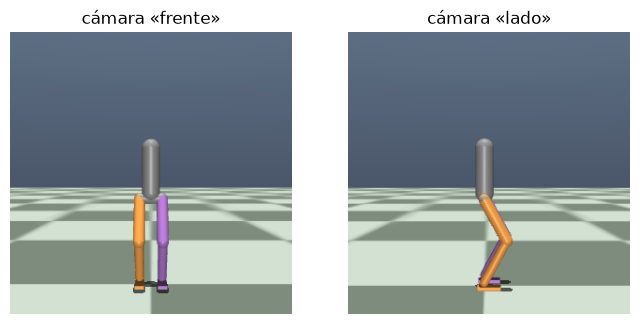

In [17]:
Path("robots/zancudo3d.xml").write_text(spec.to_xml(), encoding="utf-8")

datos3d = mujoco.MjData(zancudo3d)
mujoco.mj_resetDataKeyframe(zancudo3d, datos3d, zancudo3d.key("agachado").id)
mujoco.mj_forward(zancudo3d, datos3d)
print("centro de masas:", datos3d.subtree_com[1].round(4))

camara = mujoco.Renderer(zancudo3d, height=300, width=300)
fig, ejes = plt.subplots(1, 2, figsize=(8, 4))
for ax, nombre in zip(ejes, ["frente", "lado"]):
    camara.update_scene(datos3d, camera=nombre)
    ax.imshow(camara.render())
    ax.set_title(f"cámara «{nombre}»")
    ax.axis("off")
plt.show()

El CdM, a 0,709 m de altura y 4,3 cm por delante del tobillo: igual que el Zancudo plano (NB51). De frente se ven las dos piernas paralelas, separadas 20 cm; de lado, la postura agachada que ya conoces.

### Dónde está cada cosa

Con una base flotante, los índices se complican. Esta tabla es de las que conviene imprimir **siempre** que se empieza con un robot nuevo: para cada articulación, su posición en `qpos` (`qposadr`) y en `qvel` (`dofadr`):


In [18]:
print(f"{'articulación':>16} | qpos | qvel")
for j in range(zancudo3d.njnt):
    articulacion = zancudo3d.joint(j)
    print(f"{articulacion.name:>16} | {articulacion.qposadr[0]:4d} | {articulacion.dofadr[0]:4d}")

    articulación | qpos | qvel
            raiz |    0 |    0
   cadera_giro_d |    7 |    6
   cadera_lado_d |    8 |    7
        cadera_d |    9 |    8
       rodilla_d |   10 |    9
       tobillo_d |   11 |   10
  tobillo_lado_d |   12 |   11
   cadera_giro_i |   13 |   12
   cadera_lado_i |   14 |   13
        cadera_i |   15 |   14
       rodilla_i |   16 |   15
       tobillo_i |   17 |   16
  tobillo_lado_i |   18 |   17


La raíz ocupa `qpos[0:7]` y `qvel[0:6]`; después, **todas las demás van desplazadas una posición**: `cadera_giro_d` es `qpos[7]` pero `qvel[6]`. Por eso, en el código que viene, los ángulos de los motores serán siempre `qpos[7:]` y sus velocidades `qvel[6:]`.


## 6 · Cinemática inversa de la pierna en 3D

En el NB52 resolvimos la pierna plana con la ley del coseno. En 3D hay un truco que la reduce a ese mismo caso: el **alabeo de la cadera** inclina el plano de la pierna hacia un lado, y **dentro de ese plano inclinado** la pierna es la misma cadena de dos eslabones de siempre.

Con el vector de la cadera al tobillo, (dx, dy, dz), con dz negativo (el tobillo está debajo):

1. **Alabeo de cadera**: el ángulo de ese vector visto **de frente**: `atan2(dy, −dz)`. Inclina la pierna hacia donde esté el tobillo.
2. **Dentro del plano inclinado**, la distancia "hacia abajo" ya no es −dz, sino `√(dy² + dz²)` (la hipotenusa, Pitágoras). Con ella y dx, la IK plana del NB52: rodilla por la ley del coseno, cadera = ángulo − rodilla/2.
3. **Tobillo**: el cabeceo deshace la cadera y la rodilla (como en el NB52), y el **alabeo del tobillo deshace el de la cadera** (con el signo contrario). Así, la planta queda horizontal.
4. **Giro de cadera**: 0 (hoy no giramos los pies).

Fíjate en el paso 3: si alabeo de cadera = −alabeo de tobillo, la pierna forma un **paralelogramo** visto de frente: la pelvis se desplaza de lado, pero sigue horizontal, y el pie también. Es como se pasa el peso de un pie a otro.


In [19]:
def ik_pierna3d(cadera, tobillo, largo):
    '''Ángulos de los 6 motores de una pierna para poner el tobillo en su sitio con la planta horizontal.'''
    dx, dy, dz = np.subtract(tobillo, cadera)
    lado = math.atan2(dy, -dz)
    abajo = math.hypot(dy, dz)
    coseno = (dx ** 2 + abajo ** 2 - 2 * largo ** 2) / (2 * largo ** 2)
    rodilla = -math.acos(min(1.0, max(-1.0, coseno)))
    cadera_cabeceo = math.atan2(dx, abajo) - rodilla / 2
    return [0.0, lado, cadera_cabeceo, rodilla, -(cadera_cabeceo + rodilla), -lado]

d = mujoco.MjData(zancudo3d)
cadera = np.array([0.0, -0.1, 0.767])
for objetivo in [(0.05, -0.1, 0.065), (0.0, -0.02, 0.065), (0.1, -0.15, 0.12)]:
    d.qpos[:] = 0
    d.qpos[2], d.qpos[3] = 0.767, 1.0
    d.qpos[7:13] = ik_pierna3d(cadera, objetivo, 0.4)
    mujoco.mj_kinematics(zancudo3d, d)
    pie = zancudo3d.body("pie_d").id
    normal = d.xmat[pie].reshape(3, 3)[:, 2]                  # el eje z del pie, en el mundo
    print(f"pedido {objetivo} → tobillo {d.xpos[pie].round(6)}   planta mirando a {normal.round(6)}")

pedido (0.05, -0.1, 0.065) → tobillo [ 0.05  -0.1    0.065]   planta mirando a [0. 0. 1.]
pedido (0.0, -0.02, 0.065) → tobillo [ 0.    -0.02   0.065]   planta mirando a [0. 0. 1.]
pedido (0.1, -0.15, 0.12) → tobillo [ 0.1  -0.15  0.12]   planta mirando a [-0.  0.  1.]


(`math.hypot(a, b)` es √(a² + b²) de un golpe, y más precisa que hacerlo a mano. `np.subtract(a, b)` resta dos listas como arrays.)

Los tres tobillos, en su sitio hasta el sexto decimal. Y la "normal" de la planta, el eje z del pie (la tercera columna de su matriz de rotación, NB46), es (0, 0, 1): **mirando hacia arriba**, planta horizontal, también con el tobillo desplazado de lado (el segundo caso, con la pierna inclinada hacia dentro) y levantado y de lado a la vez (el tercero).


## 7 · De pie, con la gravedad compensada

### El problema de los servos blandos

Pongamos a Zancudo 3D de pie en `agachado`, con los motores pidiendo esa postura, y miremos cuánto se hunde. Primero con servos **blandos** (kp = 300, kv = 20, los de fábrica del Zancudo plano) y luego con los **rígidos** (kp = 3.000, kv = 90):


In [20]:
def de_pie(cfg, prealimentacion=None, segundos=5.0):
    '''Zancudo 3D de pie en «agachado». Devuelve el error máximo de las articulaciones y la carga de cada pie.'''
    m = construir(cfg).compile()
    d = mujoco.MjData(m)
    mujoco.mj_resetDataKeyframe(m, d, m.key("agachado").id)
    referencia = d.qpos[7:].copy()
    if prealimentacion is not None:
        d.ctrl[:] = referencia + prealimentacion / cfg.motores.kp
    for _ in range(round(segundos / m.opt.timestep)):
        mujoco.mj_step(m, d)
    return np.abs(d.qpos[7:] - referencia).max(), d.sensor("tacto_d").data[0], d.sensor("tacto_i").data[0]

for kp, kv in [(300.0, 20.0), (3000.0, 90.0)]:
    cfg = replace(config, motores=Motores(kp=kp, kv=kv))
    error, carga_d, carga_i = de_pie(cfg)
    print(f"kp = {kp:>6}: error máximo {error:.4f} rad   carga de los pies {carga_d:.1f} N y {carga_i:.1f} N")

kp =  300.0: error máximo 0.0528 rad   carga de los pies 115.8 N y 115.8 N


kp = 3000.0: error máximo 0.0047 rad   carga de los pies 115.8 N y 115.8 N


Con los servos blandos, las articulaciones se apartan **0,053 rad** (3°) de lo pedido: el robot se **hunde** un poco, porque el PD necesita error para hacer fuerza (NB52). Con los rígidos, 0,005. Cada pie carga **115,8 N**: entre los dos, 231,5 N = 23,6 kg × 9,81 m/s², el peso entero.

En el NB52 lo arreglamos subiendo kp. Pero los robots modernos (los que se entrenan con RL, los que trabajan cerca de personas) suelen preferir servos **blandos**: absorben mejor los golpes y son más seguros. La solución profesional es la del NB47: **prealimentar el par** que hace falta para aguantar la gravedad. Pero con un robot que se apoya en el suelo, hay un problema nuevo.

### ¿Quién sostiene al robot?

En el NB47 compensamos la gravedad de una pierna **colgada**: el par de cada articulación era el de la gravedad, `qfrc_bias`, y ya está. Aquí no basta. El robot está apoyado: el **suelo** empuja los pies hacia arriba, y esas fuerzas también producen pares en las articulaciones. La ecuación del equilibrio (NB45: M·q̈ + sesgo = pares de los motores + fuerzas del suelo; con q̈ = 0):

```
sesgo  =  pares de los motores  +  Jᵀ · F
```

- **sesgo** (`qfrc_bias`, 18 números): lo que "pide" la gravedad en cada grado de libertad.
- **F**: las fuerzas del suelo en los pies. Para cada pie, una fuerza (3 números) y un par (3 números): 6 por pie, 12 en total.
- **Jᵀ · F**: cómo se traducen esas fuerzas en pares articulares: el **jacobiano traspuesto** del NB46 ("de fuerzas a pares"), con el jacobiano de la planta de cada pie (`mj_jacSite`).
- **Pares de los motores**: 0 en las 6 primeras filas (la base flotante **no tiene motores**), y lo que queremos saber en las 12 restantes.

### El truco: la base no tiene motores

Mira las **6 primeras filas** de la ecuación (las de la base). Como allí no hay motores:

```
sesgo[0:6]  =  J[:, 0:6]ᵀ · F
```

**Seis ecuaciones** que dicen: las fuerzas del suelo tienen que sostener al robot entero (fuerza total = peso, y momento total = 0). Y **12 incógnitas** (las fuerzas de los dos pies). Más incógnitas que ecuaciones: hay **infinitas** formas de repartir el peso entre los pies (más en uno, más en otro, empujando un poco hacia dentro...). Hay que elegir una.

La elección más sencilla: la de **norma mínima**, la que usa fuerzas "lo más pequeñas posible" (en conjunto). Es lo que da `np.linalg.lstsq` cuando hay más incógnitas que ecuaciones (los mínimos cuadrados del NB46, P7). Con las fuerzas elegidas, las 12 filas de los motores dan los pares:

```
pares de los motores  =  (sesgo − Jᵀ · F)[6:]
```

Esto se llama **reparto de fuerzas** (*force distribution*), y es el corazón del **control de todo el cuerpo** (*whole-body control*, NB47), el que usaba Atlas: en cada instante, decidir cómo se reparten las fuerzas entre los contactos, y de ahí sacar los pares.


In [21]:
def pares_de_pie(m, d, pies=("planta_d", "planta_i")):
    '''Pares de los motores que sostienen la postura de d (quieta), repartiendo el peso entre los pies.'''
    mujoco.mj_forward(m, d)
    sesgo = d.qfrc_bias.copy()
    bloques = []
    for nombre in pies:
        jac_pos, jac_giro = np.zeros((3, m.nv)), np.zeros((3, m.nv))
        mujoco.mj_jacSite(m, d, jac_pos, jac_giro, m.site(nombre).id)
        bloques.append(np.vstack([jac_pos, jac_giro]))           # 6 filas por pie: fuerza y par
    J = np.vstack(bloques)                                       # (6 · nº de pies) × nv
    F, *_ = np.linalg.lstsq(J[:, :6].T, sesgo[:6], rcond=None)   # 6 ecuaciones de la base
    pares = sesgo - J.T @ F
    return pares[6:], F

m = construir(config).compile()
d = mujoco.MjData(m)
mujoco.mj_resetDataKeyframe(m, d, m.key("agachado").id)
pares, F = pares_de_pie(m, d)
print("pares de los motores (N·m):", pares.round(2))
print("fuerza vertical del suelo en cada pie:", F[2].round(1), "y", F[8].round(1), "N")

pares de los motores (N·m): [ 0.    0.    0.   14.11 -4.7   0.    0.    0.    0.   14.11 -4.7   0.  ]
fuerza vertical del suelo en cada pie: 115.8 y 115.8 N


(`F, *_ = ...` recoge lo primero que devuelve `lstsq` y descarta el resto, P1: `lstsq` devuelve cuatro cosas.)

El reparto pone **115,8 N en cada pie** (la componente z de la fuerza de cada uno: `F[2]` y `F[8]`), justo lo que medía el sensor de tacto: la norma mínima, con un robot simétrico, reparte a partes iguales. Y los pares: **14,1 N·m en cada rodilla** y **−4,7 en cada tobillo**; el resto, cero (la cadera no hace par porque el torso está justo encima). Prealimentémoslos (ctrl = q + par/kp, el truco del NB52, pero con el par en vez de la velocidad):


In [22]:
for kp, kv in [(300.0, 20.0), (3000.0, 90.0)]:
    cfg = replace(config, motores=Motores(kp=kp, kv=kv))
    error, carga_d, carga_i = de_pie(cfg, prealimentacion=pares)
    print(f"kp = {kp:>6}, con prealimentación: error máximo {error:.6f} rad   cargas {carga_d:.1f} y {carga_i:.1f} N")

kp =  300.0, con prealimentación: error máximo 0.000039 rad   cargas 115.8 y 115.8 N


kp = 3000.0, con prealimentación: error máximo 0.000002 rad   cargas 115.8 y 115.8 N


**Error prácticamente cero** (4·10⁻⁵ rad: unas 10.000 veces menos que antes con los servos blandos). Los motores ya no necesitan "hundirse" para hacer fuerza: les damos la fuerza que hace falta por adelantado, y el PD solo tiene que corregir las desviaciones. Es la idea de todos los controladores modernos: **lo que sabes, prealiméntalo; la realimentación, para lo que no sabes**.


## 8 · Mover el centro de masas en 2D

Para sostenerse a la pata coja, hay que llevar el CdM **encima del pie** de apoyo: 10 cm hacia un lado. Como en el NB52, elegimos dónde está la **pelvis**, y el CdM queda donde quede. Pero ahora la búsqueda es en **2D**: hay que encontrar (x, y) de la pelvis para que el CdM quede en (x, y) objetivo.

La secante del NB52 se generaliza a varias dimensiones con el **método de Newton**: en vez de una pendiente, una **matriz de pendientes**, el **jacobiano** de "CdM en función de la pelvis" (2 × 2), que estimamos moviendo la pelvis un poquito en x y luego en y (diferencias finitas, NB46). Y en vez de dividir el error entre la pendiente, **resolvemos** J · corrección = error (`np.linalg.solve`):


In [23]:
ANCHO = config.torso.ancho_cadera / 2
ALTURA_CADERA = m.key_qpos[0][2]
ALTO_TOBILLO = config.pie.alto + 0.035
calc = mujoco.MjData(m)                                  # datos propios para la IK (NB52)

def postura(pelvis_xy, tobillo_d, tobillo_i):
    q = np.zeros(m.nq)
    q[0:2], q[2], q[3] = pelvis_xy, ALTURA_CADERA, 1.0
    q[7:13] = ik_pierna3d([pelvis_xy[0], pelvis_xy[1] - ANCHO, ALTURA_CADERA], tobillo_d, 0.4)
    q[13:19] = ik_pierna3d([pelvis_xy[0], pelvis_xy[1] + ANCHO, ALTURA_CADERA], tobillo_i, 0.4)
    return q

def cdm_de(q):
    calc.qpos[:] = q
    mujoco.mj_kinematics(m, calc)
    mujoco.mj_comPos(m, calc)
    return calc.subtree_com[1][:2].copy()

def ik_cdm(objetivo, tobillo_d, tobillo_i, pelvis=(0.0, 0.0), tolerancia=1e-8, verbose=False):
    pelvis = np.array(pelvis, dtype=float)
    for vuelta in range(10):
        actual = cdm_de(postura(pelvis, tobillo_d, tobillo_i))
        error = objetivo - actual
        if verbose:
            print(f"vuelta {vuelta}: error del CdM {np.abs(error).max():.1e} m")
        if np.abs(error).max() < tolerancia:
            break
        J = np.zeros((2, 2))
        for k in range(2):                                # diferencias finitas: mover x, luego y
            movida = pelvis.copy()
            movida[k] += 1e-4
            J[:, k] = (cdm_de(postura(movida, tobillo_d, tobillo_i)) - actual) / 1e-4
        pelvis = pelvis + np.linalg.solve(J, error)
    return postura(pelvis, tobillo_d, tobillo_i), pelvis

TOBILLO_D = np.array([0.0, -ANCHO, ALTO_TOBILLO])
TOBILLO_I = np.array([0.0, ANCHO, ALTO_TOBILLO])
q, pelvis = ik_cdm(np.array([0.04, -0.1]), TOBILLO_D, TOBILLO_I, verbose=True)
print("pelvis en", pelvis.round(4), " → alabeo de cadera derecha:", round(q[8], 4), "rad")

vuelta 0: error del CdM 1.0e-01 m
vuelta 1: error del CdM 2.6e-03 m
vuelta 2: error del CdM 2.2e-06 m
vuelta 3: error del CdM 5.2e-11 m
pelvis en [-0.001  -0.1348]  → alabeo de cadera derecha: 0.1898 rad


Tres correcciones: el error pasa de 10 cm a 2,6 mm, a 2 micras, a 5·10⁻¹¹ m: en cada vuelta, el número de cifras correctas casi se duplica, la convergencia de Newton (NB52). Para poner el CdM sobre el pie derecho (y = −0,1), la pelvis tiene que ir **más allá**, a −0,135: las piernas pesan, y la izquierda se queda atrás, tirando del CdM hacia su lado. Las piernas se inclinan de lado 0,19 rad (unos 11°).


## 9 · A la pata coja

### El plan

Una secuencia de 10 segundos, con transiciones suaves (el perfil quíntico del NB51, para que nada empiece ni acabe de golpe):

1. **0-1 s**: de pie, quieto.
2. **1-3 s**: llevar el CdM de (0,04, 0) a (0,04, −0,1), encima del pie derecho.
3. **3,5-4,5 s**: levantar el pie izquierdo 5 cm.
4. **4,5-6,5 s**: **a la pata coja**.
5. **6,5-7,5 s**: bajar el pie. **8-10 s**: devolver el CdM al centro.

En cada instante (cada 10 ms): los objetivos → IK del CdM (Newton) → ángulos → prealimentación → servos.

### ¿Cómo se reparte el peso mientras se pasa de un pie a otro?

Aquí aparece una sutileza. Con la **norma mínima**, el reparto de fuerzas **siempre** pone la mitad del peso en cada pie mientras los dos estén en el suelo... aunque el CdM esté ya casi encima del pie derecho. Y eso es **físicamente falso**: si el CdM está sobre el pie derecho, el izquierdo apenas carga. Prealimentar unos pares calculados con un reparto falso es **empujar** al robot hacia donde no queremos.

Mejor: un reparto **ponderado**, en el que cada pie carga según dónde está el CdM. Si el CdM está a medio camino, 50 % y 50 %; si está encima del derecho, 100 % y 0 %; en medio, la proporción. Matemáticamente, buscamos las fuerzas que cumplen las 6 ecuaciones de la base y minimizan Σ (fuerza del pie)² / (su fracción): un pie con una fracción pequeña "cuesta mucho" cargarlo. Tiene una fórmula cerrada, la de los **mínimos cuadrados ponderados**:

```
F  =  W · Aᵀ · (A · W · Aᵀ)⁻¹ · sesgo[0:6]        con A = J[:, 0:6]ᵀ y W = las fracciones, en diagonal
```

(No hace falta memorizarla: es la de norma mínima con unos pesos dentro. Con todas las fracciones iguales, da exactamente lo mismo que `lstsq`.)


In [24]:
def pares_de_pie_ponderado(m, d, cargas):
    '''Como pares_de_pie, pero cada pie carga según su fracción: cargas = {site: fracción}.'''
    mujoco.mj_forward(m, d)
    sesgo = d.qfrc_bias.copy()
    pies = [nombre for nombre, fraccion in cargas.items() if fraccion > 1e-3]
    bloques, pesos = [], []
    for nombre in pies:
        jac_pos, jac_giro = np.zeros((3, m.nv)), np.zeros((3, m.nv))
        mujoco.mj_jacSite(m, d, jac_pos, jac_giro, m.site(nombre).id)
        bloques.append(np.vstack([jac_pos, jac_giro]))
        pesos += [cargas[nombre]] * 6
    J = np.vstack(bloques)
    A, W = J[:, :6].T, np.diag(pesos)
    F = W @ A.T @ np.linalg.solve(A @ W @ A.T, sesgo[:6])
    return (sesgo - J.T @ F)[6:], F

def suave(s):
    s = min(max(s, 0.0), 1.0)
    return 10 * s ** 3 - 15 * s ** 4 + 6 * s ** 5      # el quíntico del NB51

def objetivos(t):
    '''CdM, tobillos y fracción de peso en el pie derecho, en el instante t.'''
    hacia_derecha = suave((t - 1) / 2) - suave((t - 8) / 2)
    levantado = suave((t - 3.5) / 1) - suave((t - 6.5) / 1)
    cdm = np.array([0.04, -0.1 * hacia_derecha])
    tobillo_i = TOBILLO_I + np.array([0, 0, 0.05 * levantado])
    fraccion_d = 1.0 if levantado > 0.01 else float(np.clip((ANCHO - cdm[1]) / (2 * ANCHO), 0, 1))
    return cdm, tobillo_i, fraccion_d, levantado

La fracción del pie derecho sale de dónde está el CdM entre los dos pies: (ancho − y)/(2 · ancho), que vale 0,5 con el CdM en el centro (y = 0) y 1 con el CdM encima del pie derecho (y = −0,1). En cuanto el pie izquierdo se levanta, el derecho carga el 100 %.

Ahora, la simulación. Una función que prueba la secuencia con unos servos y un tipo de prealimentación (ninguna, de norma mínima o ponderada), y devuelve el error máximo del CdM (o el instante en que se cae). Usa también la prealimentación de **velocidad** del NB52:


In [25]:
def pata_coja(cfg, prealimentacion="ponderada", al_paso=None):
    m_ = construir(cfg).compile()
    d_ = mujoco.MjData(m_)
    kp, kv = cfg.motores.kp, cfg.motores.kv
    q, pelvis = ik_cdm(np.array([0.04, 0.0]), TOBILLO_D, TOBILLO_I)
    d_.qpos[:] = q
    mujoco.mj_forward(m_, d_)
    anterior, errores = q[7:].copy(), []
    for k in range(1000):                                         # 10 s, cada 10 ms
        t = k * 0.01
        cdm, tobillo_i, fraccion_d, levantado = objetivos(t)
        q, pelvis = ik_cdm(cdm, TOBILLO_D, tobillo_i, pelvis)
        orden = q[7:] + (kv / kp) * (q[7:] - anterior) / 0.01      # prealimentación de velocidad
        anterior = q[7:].copy()
        if prealimentacion is not None:
            calc.qpos[:] = q
            if prealimentacion == "ponderada":
                pares, _ = pares_de_pie_ponderado(m, calc, {"planta_d": fraccion_d, "planta_i": 1 - fraccion_d})
            else:
                pares, _ = pares_de_pie(m, calc, ("planta_d",) if levantado > 0.01 else ("planta_d", "planta_i"))
            orden = orden + pares / kp
        d_.ctrl[:] = orden
        for _ in range(5):
            mujoco.mj_step(m_, d_)
        if al_paso is not None:
            al_paso(d_)
        errores.append(np.abs(d_.subtree_com[1][:2] - cdm).max())
        if d_.qpos[2] < 0.5:
            return f"se cae a los {t:.1f} s"
    return f"error máximo del CdM {max(errores) * 100:.1f} cm"

for kp, kv in [(3000.0, 90.0), (300.0, 20.0)]:
    cfg = replace(config, motores=Motores(kp=kp, kv=kv))
    for tipo in [None, "mínima norma", "ponderada"]:
        print(f"kp = {kp:>6}, prealimentación {str(tipo):>13}: {pata_coja(cfg, tipo)}")

kp = 3000.0, prealimentación          None: se cae a los 8.9 s


kp = 3000.0, prealimentación  mínima norma: error máximo del CdM 2.2 cm


kp = 3000.0, prealimentación     ponderada: error máximo del CdM 0.4 cm
kp =  300.0, prealimentación          None: se cae a los 3.2 s


kp =  300.0, prealimentación  mínima norma: se cae a los 3.2 s


kp =  300.0, prealimentación     ponderada: error máximo del CdM 1.6 cm


(La IK y los pares se calculan con el modelo `m` de la configuración base: solo depende de la geometría y las masas, que no cambian al cambiar los motores.)

Los resultados cuentan una historia completa:

| Servos | Sin prealimentar | Norma mínima | Ponderada |
|---|---|---|---|
| **Rígidos** (kp = 3.000) | se cae (al volver a apoyar) | 2,2 cm de error | **0,4 cm** |
| **Blandos** (kp = 300) | se cae | se cae | **1,6 cm** |

- Sin prealimentar, ni los rígidos lo consiguen: al pasar el peso, el error de los PD desplaza el CdM, y en algún momento (al apoyar el pie otra vez) se sale del pie.
- Con la norma mínima, los rígidos aguantan pero con 2,2 cm de error: la prealimentación "falsa" empuja, y la rigidez lo compensa a la fuerza. Los blandos no pueden compensarlo, y se caen.
- Con el reparto **ponderado**, los rígidos siguen el CdM a 4 mm, y **hasta los blandos se sostienen a la pata coja**.

La lección vale oro: **con un buen modelo de las fuerzas, no hace falta un robot rígido**. Es exactamente la dirección que ha tomado la robótica: motores más blandos, más seguros, con más inteligencia en el control (o en la política de RL).

### Verlo

Un GIF de la versión con servos blandos, con la cámara de frente (así se ve el desplazamiento lateral):


error máximo del CdM 1.6 cm


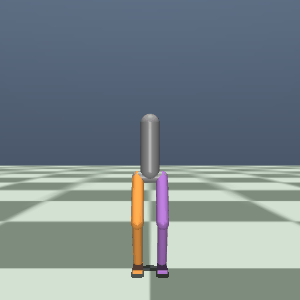

In [26]:
import imageio
from IPython.display import Image

def grabadora(modelo, camara="frente", cada=4):
    render = mujoco.Renderer(modelo, height=300, width=300)
    fotos, cuenta = [], [0]
    def al_paso(d):
        if cuenta[0] % cada == 0:
            render.update_scene(d, camera=camara)
            fotos.append(render.render())
        cuenta[0] += 1
    return fotos, al_paso

blando = replace(config, motores=Motores(kp=300.0, kv=20.0))
fotos, al_paso = grabadora(construir(blando).compile())
print(pata_coja(blando, "ponderada", al_paso=al_paso))
imageio.mimsave("assets/nb53_pata_coja.gif", fotos, fps=25, loop=0)
Image(filename="assets/nb53_pata_coja.gif")

Zancudo pasa el peso a la derecha (la pelvis se desplaza y las piernas se inclinan en paralelogramo), levanta el pie izquierdo, aguanta dos segundos a la pata coja, y vuelve. Con servos blandos.


## 10 · Equilibrio lateral: los números del NB51

### El LIPM en 3D

En el NB51 ya planificamos en 2D (x e y), y la ecuación del LIPM era la misma en las dos direcciones, por separado:

```
aceleración en x  =  ω² · (x − p_x)         aceleración en y  =  ω² · (y − p_y)
```

Las dos direcciones son **independientes** (mientras la altura sea constante), con la **misma** ω. Lo único que cambia de una a otra es el **polígono de apoyo**: hacia delante, el pie es largo (de la punta del pie al centro, 10 cm); de lado, depende de cuántos pies:

- **Dos pies**, de lado: desde el centro hasta el borde exterior de un pie: ancho de cadera/2 + ancho del pie/2 = 0,1 + 0,04 = **14 cm**.
- **Un pie**, de lado: solo medio pie: **4 cm**. Muy poco. Por eso estar a la pata coja es tan delicado (y por eso, al andar, el apoyo simple es el momento crítico).

La capturabilidad con 0 pasos del NB51 dice que el empujón máximo es ω × (distancia del CdM al borde). Midámoslo en Zancudo 3D, de pie quieto, con empujones de 0,1 s en x y en y, con dos pies y con uno, buscando el máximo por **búsqueda binaria** (NB48):


In [27]:
OMEGA = math.sqrt(9.81 / 0.71)

def aguanta(cfg, fuerza, eje, una_pierna=False, segundos=4.0):
    '''¿Sigue de pie tras un empujón de `fuerza` N durante 0,1 s en el eje dado (0 = x, 1 = y)?'''
    m_ = construir(cfg).compile()
    calc_ = mujoco.MjData(m_)
    ancho = cfg.torso.ancho_cadera / 2
    alto = cfg.pie.alto + 0.035
    tob_d, tob_i = np.array([0.0, -ancho, alto]), np.array([0.0, ancho, alto])
    if una_pierna:
        cdm, tob_i, cargas = np.array([cfg.pie.adelanto, -ancho]), tob_i + [0, 0, 0.05], {"planta_d": 1.0}
    else:
        cdm, cargas = np.array([cfg.pie.adelanto, 0.0]), {"planta_d": 0.5, "planta_i": 0.5}
    # la IK, con la geometría de esta configuración
    def postura_(p):
        q = np.zeros(m_.nq)
        q[0:2], q[2], q[3] = p, m_.key_qpos[0][2], 1.0
        q[7:13] = ik_pierna3d([p[0], p[1] - ancho, q[2]], tob_d, cfg.pierna.muslo)
        q[13:19] = ik_pierna3d([p[0], p[1] + ancho, q[2]], tob_i, cfg.pierna.muslo)
        return q
    def cdm_(q):
        calc_.qpos[:] = q
        mujoco.mj_kinematics(m_, calc_)
        mujoco.mj_comPos(m_, calc_)
        return calc_.subtree_com[1][:2].copy()
    p = np.zeros(2)
    for _ in range(10):
        actual = cdm_(postura_(p))
        J = np.column_stack([(cdm_(postura_(p + 1e-4 * e)) - actual) / 1e-4 for e in np.eye(2)])
        p = p + np.linalg.solve(J, cdm - actual)
    q = postura_(p)
    calc_.qpos[:] = q
    pares, _ = pares_de_pie_ponderado(m_, calc_, cargas)
    d_ = mujoco.MjData(m_)
    d_.qpos[:] = q
    d_.ctrl[:] = q[7:] + pares / cfg.motores.kp
    torso = m_.body("torso").id
    for k in range(round(segundos / 0.01)):
        d_.xfrc_applied[torso, eje] = fuerza if 1.0 <= k * 0.01 < 1.1 else 0.0
        for _ in range(5):
            mujoco.mj_step(m_, d_)
        if 2 * math.asin(min(1.0, np.linalg.norm(d_.qpos[4:7]))) > 0.5:      # torso inclinado más de 0,5 rad
            return False
    return True

def empujon_maximo(cfg, eje, una_pierna=False):
    aguanta_, cae = 0.0, 800.0
    for _ in range(9):
        medio = (aguanta_ + cae) / 2
        if aguanta(cfg, medio, eje, una_pierna):
            aguanta_ = medio
        else:
            cae = medio
    return aguanta_ * 0.1 / 23.6                                  # en m/s

print(f"{'':>12} | {'eje':>3} | simulación | teoría (ω · borde)")
for una_pierna, borde_y in [(False, 0.14), (True, 0.04)]:
    for eje, nombre, borde in [(0, "x", 0.10), (1, "y", borde_y)]:
        v = empujon_maximo(config, eje, una_pierna)
        print(f"{'un pie' if una_pierna else 'dos pies':>12} | {nombre:>3} | {v:8.2f} m/s | {OMEGA * borde:.2f} m/s")

             | eje | simulación | teoría (ω · borde)


    dos pies |   x |     0.32 m/s | 0.37 m/s


    dos pies |   y |     0.44 m/s | 0.52 m/s


      un pie |   x |     0.28 m/s | 0.37 m/s


      un pie |   y |     0.11 m/s | 0.15 m/s


Dos detalles de código: `np.column_stack([... for e in np.eye(2)])` fabrica el jacobiano 2 × 2 en una línea (`np.eye(2)` son las dos direcciones (1, 0) y (0, 1), P7); y la inclinación del torso se saca del cuaternión: un giro de ángulo θ tiene un cuaternión con parte vectorial de longitud sin(θ/2) (NB46), así que θ = 2·asin(|qpos[4:7]|). (Si en vez de 0,5 rad usáramos una altura mínima, como en 2D, tardaríamos más en detectar la caída: este criterio la ve venir antes.)

La tabla:

- **Dos pies, hacia delante**: 0,32 m/s (teoría 0,37). Como el Zancudo plano del NB52 (0,30): en esa dirección, nada ha cambiado.
- **Dos pies, de lado**: unos 0,44 m/s (teoría 0,52). Más que hacia delante, porque el polígono de apoyo es más ancho (28 cm) que largo (20 cm).
- **Un pie, hacia delante**: 0,28 m/s, algo menos que con dos (el pie es igual de largo, pero sostenerse sobre uno es más delicado).
- **Un pie, de lado**: **0,11 m/s** (teoría 0,15). Un empujón de 26 N, un toquecito con un dedo, tira a Zancudo a la pata coja.

La simulación da entre el 75 y el 85 % de la teoría, por los mismos motivos que en el NB52 (el pie se levanta del borde antes de que el ZMP llegue, el contacto es blando...). Pero el **orden** de las cosas, y sus proporciones, son exactamente las del LIPM. El modelo de una línea del NB39 sigue funcionando en 3D.

### Barrido: ¿caderas más anchas?

La teoría dice que el empujón lateral con dos pies crece con el ancho de cadera: ω · (ancho/2 + ancho del pie/2). Comprobémoslo fabricando tres robots con `replace`, sin tocar una línea del constructor (para eso sirve la configuración):


In [28]:
for ancho in [0.12, 0.2, 0.3]:
    variante = replace(config, torso=replace(config.torso, ancho_cadera=ancho))
    v = empujon_maximo(variante, eje=1)
    print(f"ancho de cadera {ancho:.2f} m: empujón lateral máximo {v:.2f} m/s   (teoría {OMEGA * (ancho / 2 + 0.04):.2f})")

ancho de cadera 0.12 m: empujón lateral máximo 0.30 m/s   (teoría 0.37)


ancho de cadera 0.20 m: empujón lateral máximo 0.44 m/s   (teoría 0.52)


ancho de cadera 0.30 m: empujón lateral máximo 0.62 m/s   (teoría 0.71)


Con caderas de 12 cm, 0,30 m/s; de 20 cm, 0,44; de 30 cm, 0,62. Crece casi en línea recta, como la teoría (a un 80-87 % de ella).

Entonces, ¿por qué los humanoides no tienen las caderas muy anchas? Porque al **andar**, un robot de caderas anchas tiene que llevar el CdM **más lejos** de un pie al otro en cada paso (NB51: el balanceo lateral), lo que gasta energía y tiempo; y los pies chocarían menos, pero el robot "anadea" como un pato. Es un **compromiso** de diseño, y este tipo de barridos (con la configuración, el constructor y una prueba automática) es justo como se estudia: lo harás más en grande en el E5 y en la aleatorización del NB55.


## 11 · Resumen de la lección

1. **Base flotante**: junta libre con 7 números en `qpos` (posición + cuaternión) y 6 en `qvel`. nq = nv + 1 por cada junta libre: los motores empiezan en `qpos[7]` pero en `qvel[6]`. Comparar posturas con `mj_differentiatePos`, nunca restando.
2. **Velocidad de la junta libre**: lineal en el **mundo**, angular en el marco **local** (lo que mide un giróscopo).
3. **Pierna humanoide de 6 GDL**: cadera (giro, lado, cabeceo), rodilla, tobillo (cabeceo, lado). Varias bisagras en un cuerpo, aplicadas en orden.
4. **Configuración**: dataclasses anidadas y congeladas, valores por defecto = el robot, validación en `__post_init__`, variantes con `replace`.
5. **YAML**: sintaxis por sangría, comentarios, `safe_dump`/`safe_load` (nunca `load`). Trampas de YAML 1.1: `1e-3` es texto, `NO`/`on` son booleanos, `12:30` es 750, `0755` es 493. **Comprobar tipos y claves al cargar** (`get_type_hints`, `difflib`). Variantes como **fusión profunda** de diccionarios.
6. **Constructor con MjSpec** desde la configuración: pies planos de caja, sensores, cámaras, postura calculada; `to_xml()` para guardar.
7. **IK 3D de la pierna**: alabeo de cadera = atan2(dy, −dz); en el plano inclinado, la IK plana; tobillos que deshacen cadera (paralelogramo: planta horizontal).
8. **De pie**: 6 ecuaciones de la base (sin motores), 12 incógnitas (fuerzas de los pies): **reparto de fuerzas**; pares = (sesgo − Jᵀ·F) en los motores. Prealimentar → error 0 incluso con servos blandos.
9. **IK del CdM en 2D**: Newton con jacobiano por diferencias finitas.
10. **Pata coja**: el reparto **ponderado** por la posición del CdM es imprescindible; con él, hasta los servos blandos se sostienen.
11. **Equilibrio lateral**: LIPM independiente en x e y; empujón máximo ≈ ω · distancia al borde del apoyo (simulación ≈ 75-85 % de la teoría). A la pata coja, de lado: solo 0,11 m/s. Caderas más anchas → más equilibrio lateral (pero peor marcha).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Base flotante** | El torso de un robot con patas: 6 grados de libertad sin motor. |
| **Junta libre (*freejoint*)** | La articulación de MuJoCo para un cuerpo libre: 7 qpos, 6 qvel. |
| **Guiñada / alabeo (*yaw* / *roll*)** | Giro alrededor del eje vertical / del eje hacia delante. |
| **Reparto de fuerzas** | Decidir cuánta fuerza hace cada contacto para sostener al robot. |
| **Mínimos cuadrados ponderados** | Mínimos cuadrados en los que unas incógnitas "cuestan" más que otras. |
| **Control de todo el cuerpo** | Controlar a la vez fuerzas de contacto y articulaciones, con optimización. |
| **Paralelogramo (de la pierna)** | Alabeo de cadera y de tobillo opuestos: la pelvis se desplaza sin inclinarse. |
| **YAML** | Formato de texto para configuraciones, por sangría y con comentarios. |
| **Fusión profunda** | Combinar diccionarios anidados cambiando solo las claves indicadas. |
| **Problema de Noruega** | `NO` en YAML 1.1 se lee como `False`. |


## 12 · Preguntas de entrevista, con respuesta

**"¿Qué es una base flotante? ¿Por qué nq ≠ nv?"**
El torso de un robot con patas no está unido al mundo: tiene 6 grados de libertad sin actuar (subactuado), que solo se controlan a través de los contactos. Su orientación se guarda con un cuaternión (4 números para 3 grados de libertad), así que nq = nv + 1 por cada junta libre; los índices de qpos y qvel de las articulaciones quedan desplazados.

**"¿En qué marco está la velocidad angular de una junta libre en MuJoCo?"**
En el marco local del cuerpo (como un giróscopo); la lineal, en el mundo. Para pasar de una a otra, la matriz de rotación del cuerpo (`xmat`), o `mj_objectVelocity` con el marco que se quiera.

**"¿Qué articulaciones tiene la pierna de un humanoide?"**
Seis típicamente: cadera de 3 (guiñada para girar, alabeo para el equilibrio lateral, cabeceo para dar el paso), rodilla, y tobillo de 2 (cabeceo y alabeo, para apoyar el pie plano). Los ejes de la cadera se cortan en un punto, como una rótula; el orden varía según el fabricante.

**"¿Cómo calculas los pares para que esté de pie?"**
Equilibrio estático: sesgo = Sᵀ·τ + Jcᵀ·F. Las filas de la base flotante no tienen motores, así que dan 6 ecuaciones para las fuerzas de contacto F; con dos pies hay más incógnitas que ecuaciones, y se elige una solución (norma mínima, ponderada por la posición del CdM, o una optimización con límites de rozamiento y de ZMP, que es lo que hace un controlador de todo el cuerpo con QP). Luego τ = (sesgo − Jcᵀ·F) en las filas de los motores, y se prealimenta.

**"¿De qué depende cuánto empujón lateral aguanta un bípedo?"**
Del LIPM: empujón máximo ≈ ω · distancia del CdM al borde del polígono de apoyo (0 pasos); con pasos, de lo que crece la región de captura (NB51). De lado, con los pies juntos o a la pata coja, el polígono es muy estrecho: por eso el apoyo simple es el momento crítico de la marcha.


## 13 · Ejercicios

**E1.** Inclina a Zancudo 3D 0,1 rad hacia la derecha (un giro alrededor del eje x del mundo) usando `qpos[3:7]`, y comprueba con `mj_forward` que la "gravedad vista desde el robot" (el vector (0, 0, −1) del mundo expresado en el marco del torso, con `xmat`) refleja esa inclinación. Recupera el ángulo a partir del cuaternión con 2·asin(|qpos[4:7]|). (Esa "gravedad proyectada" será una de las observaciones clave del NB54.)

**E2.** Escribe una variante en YAML, `zancudo_pesado`, con el torso de **18 kg** y los motores a kp = 4.000, como cambios sobre la base (con `fusionar`). Constrúyela, y comprueba su masa total y cuánto carga cada pie de pie.

**E3.** Escribe una prueba automática (como las de pytest del NB27, aunque sea con `assert` en el notebook) que compruebe la ida y vuelta YAML para **20 variantes al azar**: para cada una, elige al azar el ancho de cadera (0,1-0,3), la masa del torso (5-20) y kp (100-5.000) con `np.random.default_rng(0)`, y comprueba que `desde_dict(ConfigZancudo3D, yaml.safe_load(yaml.safe_dump(asdict(c)))) == c`.

**E4.** Haz que Zancudo se sostenga a la pata coja sobre el pie **izquierdo** (cambia lo necesario en `objetivos` y en el reparto). ¿Da el mismo error que sobre el derecho? Debería: el robot es simétrico.

**E5.** Con un pie, de lado, Zancudo aguanta muy poco. Prueba con pies **más anchos** (8, 12 y 16 cm, con `replace` en `config.pie`): ¿cuánto empujón lateral aguanta a la pata coja en cada caso? Compáralo con la teoría ω · (ancho/2).

**E6.** Usa la articulación que todavía no hemos movido, el **giro de cadera**: con Zancudo de pie, gira **solo** las dos caderas 0,3 rad, dejando las demás articulaciones como están. Si los pies se quedaran quietos, el torso giraría 0,3 rad en sentido contrario. Mide cuánto giran el torso y los pies (su guiñada, a partir de sus matrices de rotación). ¿Es lo que esperabas? ¿Por qué?

**E7.** **Reto.** ¿Cuál es la rigidez **mínima** (kp, con kv = kp/15) con la que Zancudo todavía se sostiene a la pata coja con el reparto ponderado? Búscala con búsqueda binaria entre 30 y 300.


<details>
<summary>▶ Solución E1</summary>

```python
d = mujoco.MjData(m)
mujoco.mj_resetDataKeyframe(m, d, m.key("agachado").id)
angulo = 0.1
d.qpos[3:7] = [math.cos(angulo / 2), math.sin(angulo / 2), 0, 0]       # giro de 0,1 rad alrededor de x
mujoco.mj_forward(m, d)
R = d.xmat[m.body("torso").id].reshape(3, 3)          # columnas = ejes del torso, en el mundo
gravedad_local = R.T @ np.array([0, 0, -1.0])         # del mundo al marco del torso (NB46)
print("gravedad vista desde el torso:", gravedad_local.round(4))
print("ángulo desde la gravedad:", round(math.atan2(-gravedad_local[1], -gravedad_local[2]), 4))
print("ángulo desde el cuaternión:", round(2 * math.asin(np.linalg.norm(d.qpos[4:7])), 4))
```

La gravedad, vista desde el torso inclinado, ya no apunta "hacia abajo" del todo: (0, −0,0998, −0,995). Tiene una componente lateral de sin(0,1) = 0,0998, y de ahí sale el ángulo: **0,1 rad**, igual que desde el cuaternión. (`R.T @ v` pasa un vector del mundo al marco del cuerpo: la traspuesta de una rotación es su inversa, NB46.) La ventaja de la gravedad proyectada es que se puede **medir** con una IMU real (el acelerómetro, quieto, mide justo la gravedad, NB41), y no tiene las ambigüedades de los ángulos de Euler: por eso es la observación estándar de orientación en las políticas de locomoción.
</details>

<details>
<summary>▶ Solución E2</summary>

```python
PESADO = """
nombre: zancudo_pesado
torso:
  masa: 18.0
motores:
  kp: 4000.0
"""
pesado = desde_dict(ConfigZancudo3D, fusionar(asdict(config), yaml.safe_load(PESADO)))
m_pesado = construir(pesado).compile()
print("masa:", m_pesado.body_subtreemass[1])
error, carga_d, carga_i = de_pie(pesado)
print(f"cargas: {carga_d:.1f} y {carga_i:.1f} N  (peso: {m_pesado.body_subtreemass[1] * 9.81:.1f} N)")
```

Masa **29,6 kg** (6 más: el torso), y cada pie carga **145,2 N**: la mitad de 290,4 N, el peso nuevo. El fichero de la variante tiene 6 líneas, y todo lo demás (medidas, pies, rozamiento...) sale de la base. Si mañana alguien cambia el pie en la base, la variante pesada lo hereda sin tocarla.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
rng = np.random.default_rng(0)
for _ in range(20):
    c = replace(config,
                torso=replace(config.torso, ancho_cadera=float(rng.uniform(0.1, 0.3)), masa=float(rng.uniform(5, 20))),
                motores=replace(config.motores, kp=float(rng.uniform(100, 5000))))
    texto = yaml.safe_dump(asdict(c), sort_keys=False)
    assert desde_dict(ConfigZancudo3D, yaml.safe_load(texto)) == c, c
print("20 de 20: ida y vuelta perfecta")
```

Las 20 pasan. (El `float(...)` alrededor de `rng.uniform` es importante: `rng.uniform` devuelve un `np.float64`, y `yaml.safe_dump` **no** sabe guardar tipos de NumPy: daría un error. Es una trampa muy frecuente al guardar resultados de NumPy en YAML o JSON: convierte siempre a tipos de Python, con `float()`, `int()` o `.tolist()`.)
</details>

<details>
<summary>▶ Solución E4</summary>

Basta con cambiar el signo del desplazamiento del CdM, levantar el tobillo **derecho** y repartir al revés. Una forma limpia es darle a `objetivos` un parámetro de lado:

```python
def objetivos_izquierda(t):
    hacia_izquierda = suave((t - 1) / 2) - suave((t - 8) / 2)
    levantado = suave((t - 3.5) / 1) - suave((t - 6.5) / 1)
    cdm = np.array([0.04, 0.1 * hacia_izquierda])
    tobillo_d = TOBILLO_D + np.array([0, 0, 0.05 * levantado])
    fraccion_i = 1.0 if levantado > 0.01 else float(np.clip((ANCHO + cdm[1]) / (2 * ANCHO), 0, 1))
    return cdm, tobillo_d, fraccion_i, levantado

m_ = construir(config).compile()
d_ = mujoco.MjData(m_)
q, pelvis = ik_cdm(np.array([0.04, 0.0]), TOBILLO_D, TOBILLO_I)
d_.qpos[:] = q
mujoco.mj_forward(m_, d_)
anterior, errores = q[7:].copy(), []
for k in range(1000):
    cdm, tobillo_d, fraccion_i, levantado = objetivos_izquierda(k * 0.01)
    q, pelvis = ik_cdm(cdm, tobillo_d, TOBILLO_I, pelvis)
    orden = q[7:] + (90 / 3000) * (q[7:] - anterior) / 0.01
    anterior = q[7:].copy()
    calc.qpos[:] = q
    pares, _ = pares_de_pie_ponderado(m, calc, {"planta_i": fraccion_i, "planta_d": 1 - fraccion_i})
    d_.ctrl[:] = orden + pares / 3000
    for _ in range(5):
        mujoco.mj_step(m_, d_)
    errores.append(np.abs(d_.subtree_com[1][:2] - cdm).max())
print(f"error máximo del CdM: {max(errores) * 100:.1f} cm")
```

**0,4 cm**, exactamente lo mismo que sobre el pie derecho. Que dos casos que deberían ser simétricos den lo mismo es una prueba barata y muy potente de que el modelo y el código no tienen un error escondido (un eje con el signo cambiado, una pierna con otra masa...).
</details>

<details>
<summary>▶ Solución E5</summary>

```python
for ancho_pie in [0.08, 0.12, 0.16]:
    variante = replace(config, pie=replace(config.pie, ancho=ancho_pie))
    v = empujon_maximo(variante, eje=1, una_pierna=True)
    print(f"pie de {ancho_pie * 100:.0f} cm: {v:.2f} m/s   (teoría {OMEGA * ancho_pie / 2:.2f})")
```

Pie de 8 cm: **0,11 m/s**; de 12 cm: **0,17**; de 16 cm: **0,26**. Crece casi en proporción al ancho del pie, como dice la teoría (a un 73-87 % de ella). Los humanoides reales tienen pies de 10-15 cm de ancho: un compromiso entre equilibrio lateral y no tropezar con el otro pie al andar.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
m_ = construir(config).compile()
d_ = mujoco.MjData(m_)
mujoco.mj_resetDataKeyframe(m_, d_, m_.key("agachado").id)
calc.qpos[:] = d_.qpos
pares, _ = pares_de_pie(m, calc)
for k in range(300):                                   # 3 s
    giro = 0.3 * suave(k / 100)                        # gira durante el primer segundo
    orden = m_.key_ctrl[0].copy()                      # la postura agachado
    orden[[0, 6]] = giro                               # cadera_giro_d y cadera_giro_i
    d_.ctrl[:] = orden + pares / 3000
    for _ in range(5):
        mujoco.mj_step(m_, d_)
def guinada(cuerpo):
    R = d_.xmat[m_.body(cuerpo).id].reshape(3, 3)
    return math.atan2(R[1, 0], R[0, 0])                 # hacia dónde apunta su eje x, visto desde arriba
print(f"torso: {guinada('torso'):+.3f} rad   pies: {guinada('pie_d'):+.3f} y {guinada('pie_i'):+.3f} rad")
```

El torso gira **−0,145 rad** y los pies **+0,155**: la mitad cada uno, más o menos (la diferencia entre ambos sí es 0,3, lo que pedimos a las caderas). ¿Por qué no se quedan quietos los pies? Porque las demás articulaciones siguen **fijas**: cada pie cuelga recto bajo su cadera. Si el torso girase con los pies quietos, las caderas (a ±10 cm del centro) se moverían en un pequeño arco, y los pies, rígidamente debajo, tendrían que **arrastrarse** con ellas. El suelo se resiste con el rozamiento, y el resultado es un compromiso: el torso gira un poco hacia un lado, y los pies pivotan y se deslizan un poco hacia el otro.

Para girar el torso con los pies **de verdad** quietos, todas las articulaciones tienen que cooperar: la cadera gira, y además cadera, rodilla y tobillo tienen que ajustarse para que el tobillo siga en su sitio aunque la cadera se haya movido. Es decir, una **IK en 3D con el giro incluido**, no mover una articulación suelta. Es la misma lección del NB52 (la cadera no es el CdM): en un robot con los pies en el suelo, **ninguna articulación trabaja sola**.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
def aguanta_kp(kp):
    cfg = replace(config, motores=Motores(kp=kp, kv=kp / 15))
    return not pata_coja(cfg, "ponderada").startswith("se cae")

cae, aguanta_ = 30.0, 300.0
for _ in range(8):
    medio = (cae + aguanta_) / 2
    if aguanta_kp(medio):
        aguanta_ = medio
    else:
        cae = medio
print(f"kp mínimo ≈ {aguanta_:.0f}")
```

Alrededor de **kp = 220** (con kv = 15). Con menos, ni con la prealimentación perfecta aguanta: la prealimentación solo cubre la gravedad en la postura **planificada**, y las desviaciones (por las aceleraciones, los errores del modelo, el contacto) las tiene que corregir el PD, que con una rigidez demasiado baja reacciona tarde. Es el equilibrio de siempre: prealimentar lo que se sabe, y suficiente realimentación para lo que no.
</details>


## 14 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En el **NB54**, Zancudo 3D se convierte en un **entorno de locomoción profesional** para RL: un paquete de Python con su `pyproject.toml`, **comandos de velocidad** (ir a 0,5 m/s, girar...), la observación que usan los robots reales (con la **gravedad proyectada** del E1), una recompensa **modular** y un entrenamiento largo. En Python: empaquetado, línea de órdenes con `argparse`, `logging` y *fixtures* de pytest.
